In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

#loading clean data
data = pd.read_csv('D:\\python learning\\final project\\gold_stock_cleaned_2ndtry.csv', parse_dates=['Date'])

had to tell the notebook that the date column actually contains dates cus it was reading it as a string then i made the date column into the index to make query and plotting easier

In [3]:
#checking the data for null values and data types
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2968 non-null   datetime64[us]
 1   close   2968 non-null   float64       
 2   High    2968 non-null   float64       
 3   Low     2968 non-null   float64       
 4   Open    2968 non-null   float64       
 5   Vol.    2968 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 139.3 KB


Date     0
close    0
High     0
Low      0
Open     0
Vol.     0
dtype: int64

the cleaning script worked we dont have any junk rows and no null or duplicate values and the data type is correct 

In [4]:
data.head()

,Date,close,High,Low,Open,Vol.
0,2014-03-17,4.711997,4.850168,4.425026,4.425026,68200.0
1,2014-03-18,5.048568,5.278854,4.694283,4.711997,135600.0
2,2014-03-19,4.959996,5.101710,4.906854,5.013139,25600.0
3,2014-03-20,4.959996,4.959996,4.889493,4.959996,8200.0
4,2014-03-21,4.690740,4.924568,4.605712,4.924568,10600.0


In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- Theme: dark trading-terminal palette, matched to the dataset (gold stock) ----
BG        = "#0a0e14"
CARD      = "#131a24"
GRID      = "#1f2733"
TEXT      = "#e6edf3"
MUTED     = "#8b949e"
GOLD      = "#d4af37"
GOLD_BRT  = "#f0c419"
GREEN     = "#3fb950"
RED       = "#f85149"
BLUE      = "#58a6ff"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": TEXT,
    "grid.color": GRID,
    "grid.alpha": 0.6,
    "font.size": 11,
    "axes.grid": True,
    "grid.linestyle": "--",
    "legend.facecolor": CARD,
    "legend.edgecolor": GRID,
    "legend.labelcolor": TEXT,
    "savefig.facecolor": BG,
})

PLOTLY_TEMPLATE = go.layout.Template(
    layout=go.Layout(
        paper_bgcolor=BG,
        plot_bgcolor=BG,
        font=dict(color=TEXT, family="Segoe UI, Arial"),
        xaxis=dict(gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID),
        yaxis=dict(gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID),
        colorway=[GOLD, BLUE, GREEN, RED, MUTED, GOLD_BRT],
        legend=dict(bgcolor=CARD, bordercolor=GRID, borderwidth=1),
    )
)

print("Environment ready..")

Environment ready..


making costum graph colors and a theme matching the theme (gold stock change)

In [6]:

#first making a column for daily returns, log returns, moving averages, volatility, drawdown, and dollar volume (using the kaggle readme file as a reference)
data["DailyReturn"]   = data["close"].pct_change()
data["LogReturn"]     = np.log(data["close"] / data["close"].shift(1))
#mean closing price over a 50day and 200day window to identify trends and potential levels
data["MA50"]          = data["close"].rolling(50).mean()
data["MA200"]         = data["close"].rolling(200).mean()
#standard deviation of daily returns over a 21-day window, annualized by multiplying by the square root of 252 (the approximate number of trading days in a year)
data["Volatility21d"] = data["DailyReturn"].rolling(21).std() * np.sqrt(252)   # annualized, ~1 trading month window
#What is the highest closing price this stock has achieved so far?
data["RollingMax"]    = data["close"].cummax()
#This tells us how far the stock has fallen from its previous highest point.
data["Drawdown"]      = (data["close"] - data["RollingMax"]) / data["RollingMax"]
#making month and year columns for easier analysis
data["Year"]          = data["Date"].dt.year
data["Month"]         = data["Date"].dt.month
#multiplying the closing price by the volume to get the dollar volume(the total value of shares traded in a given period in dollar terms)
data["DollarVolume"]  = data["close"] * data["Vol."]

print(f"Derived fields added. Working frame: {data.shape[0]:,} rows x {data.shape[1]} columns") #i basically just added a print statement to show the number of rows and columns in the dataframe after adding the new columns
data[["Date","close","DailyReturn","MA50","MA200","Volatility21d","Drawdown"]].tail() #displaying the last 5 rows of the dataframe with the new columns added


Derived fields added. Working frame: 2,968 rows x 16 columns


,Date,close,DailyReturn,MA50,MA200,Volatility21d,Drawdown
2963,2025-12-24,34.50,0.03,28.17,24.37,0.29,-0.23
2964,2025-12-26,34.30,-0.01,28.30,24.42,0.30,-0.23
2965,2025-12-29,33.14,-0.03,28.38,24.45,0.34,-0.26
2966,2025-12-30,33.17,0.00,28.50,24.48,0.30,-0.26
2967,2025-12-31,33.76,0.02,28.62,24.51,0.30,-0.25


How has Barrick Gold's closing price changed from 2014–2025?

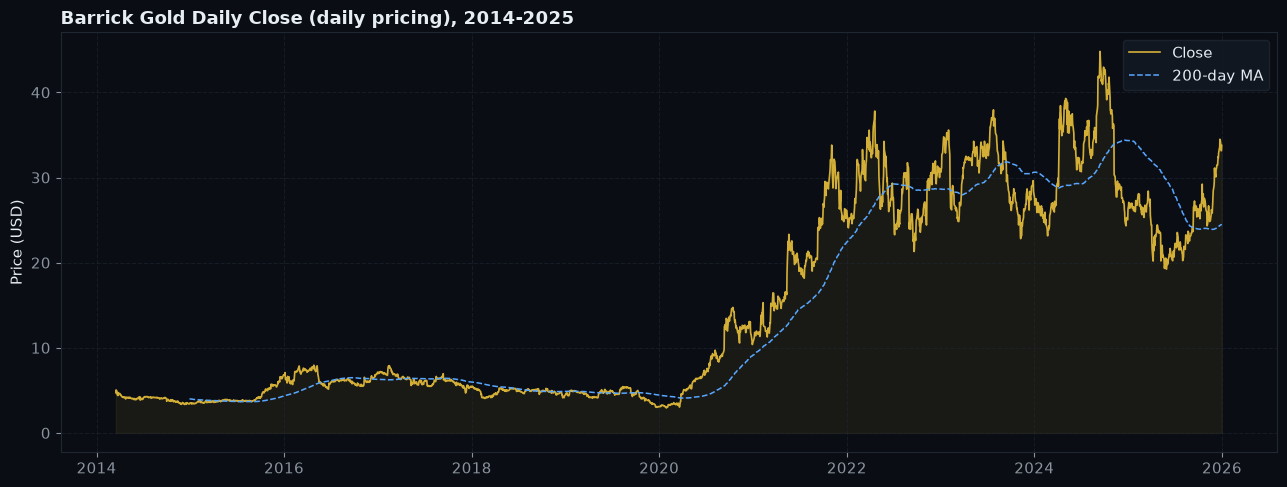

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(data["Date"], data["close"], color=GOLD, linewidth=1.2, label="Close")
ax.fill_between(data["Date"], data["close"], color=GOLD, alpha=0.08)
ax.plot(data["Date"], data["MA200"], color=BLUE, linewidth=1.1, linestyle="--", label="200-day MA")

ax.set_title("Barrick Gold Daily Close (daily pricing), 2014-2025 ", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (USD)")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

this graph shows that peak was at around 2025 then it hit bottom and now its normal again (just basic price change over the years)

how deep do the dips Get?

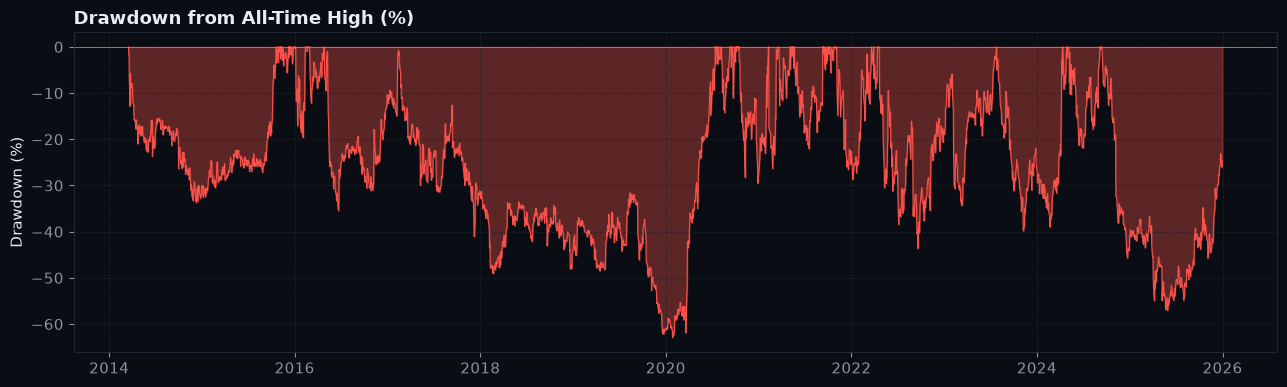

Maximum drawdown: -62.9%  (on 2020-01-28)
Median drawdown across the full period: -25.0%
Share of trading days more than 10% below the running high: 83.2%


In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(data["Date"], data["Drawdown"]*100, 0, color=RED, alpha=0.35)
ax.plot(data["Date"], data["Drawdown"]*100, color=RED, linewidth=0.8)
#title, yaxis label and horizontal line at 0% drawdown
ax.set_title("Drawdown from All-Time High (%)", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Drawdown (%)")
ax.axhline(0, color=MUTED, linewidth=0.6)
plt.tight_layout()
plt.show()
#making the drawdown analysis more informative by calculating the maximum drawdown the date of the maximum drawdown the median drawdown across the full period, and the share of trading days more than 10% below the running high
max_dd = data["Drawdown"].min()
max_dd_date = data.loc[data["Drawdown"].idxmin(), "Date"].date()
print(f"Maximum drawdown: {max_dd:.1%}  (on {max_dd_date})")
print(f"Median drawdown across the full period: {data['Drawdown'].median():.1%}")
time_underwater = (data["Drawdown"] < -0.10).mean()
print(f"Share of trading days more than 10% below the running high: {time_underwater:.1%}")

highest drawdown seen in 2020 (-62.9% from the highest point). this basically means that stock wasnt doing well on that day

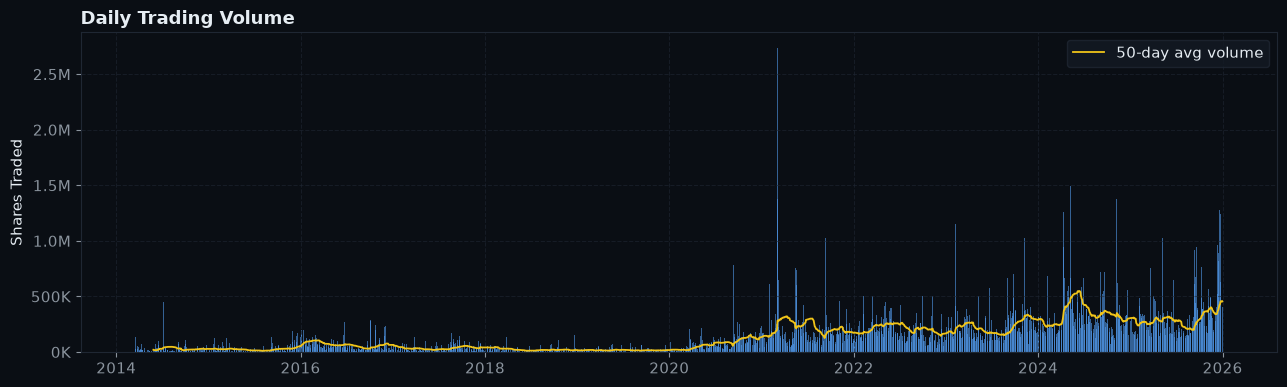

Average daily volume by year (shares):
Year
2014     29,028
2015     28,125
2016     64,708
2017     34,751
2018     20,038
2019     16,436
2020     85,803
2021    220,594
2022    208,202
2023    234,046
2024    348,017
2025    319,174
Name: Vol., dtype: str


In [9]:
#removing days with zero volume from the analysis to avoid messing up the results
vol_clean = data[data["Vol."] > 0].copy()

fig, ax = plt.subplots(figsize=(13, 4))
#bar graph of daily trading volume with a 50-day moving average line for trends
ax.bar(vol_clean["Date"], vol_clean["Vol."], color=BLUE, alpha=0.55, width=2)
ax.plot(vol_clean["Date"], vol_clean["Vol."].rolling(50).mean(), color=GOLD_BRT, linewidth=1.3, label="50-day avg volume")
ax.set_title("Daily Trading Volume", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Shares Traded")
#formatting the y-axis to show volume in millions for better graph
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.legend(frameon=True)
plt.tight_layout()
plt.show()
#grouping the data by year and calculating the average daily volume for each year then printing the results
vol_by_year = vol_clean.groupby("Year")["Vol."].mean()
print("Average daily volume by year (shares):")
#formatting the average daily volume by year to show commas for thousands and no decimal places using the lambda function to format the output
print(vol_by_year.apply(lambda x: f"{x:,.0f}"))

looking at this graph we can clearly see which year the volume of trade was at the maximum for the stock

Model fitted and predictions made successfully.


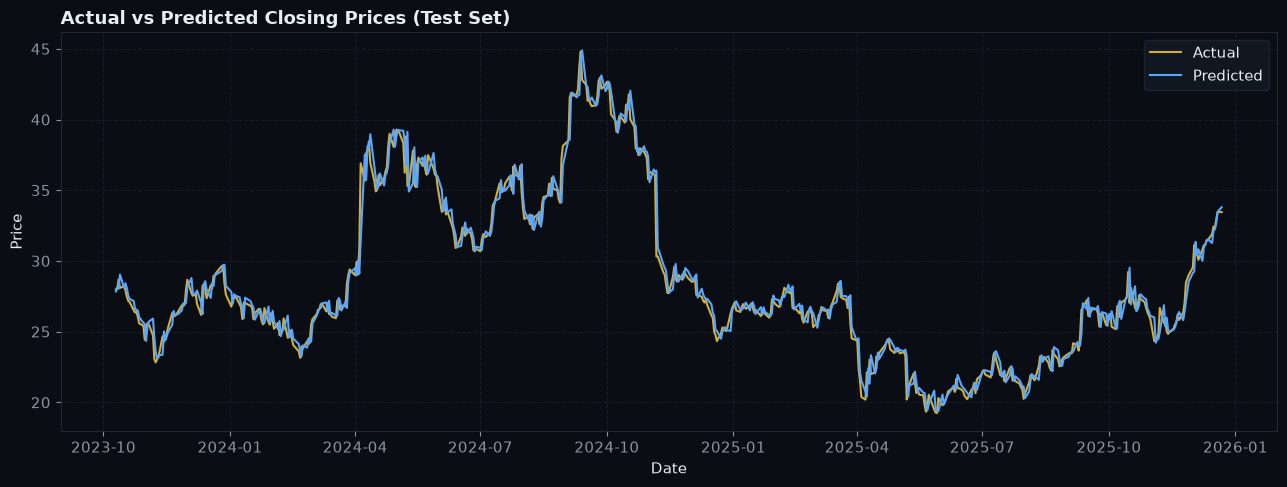

R-squared: 0.9777
Mean Absolute Error (MAE): 0.5925
Model accuracy : 0.9777


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

#i will drop NaN values here before separating the data into training and testing sets so that the model can be trained on a complete dataset
data.dropna(inplace=True)



#separating the data into training and testing sets based on the date, with the training set containing data before 2023 and the testing set containing data from 2023 onwards
data["Target"] = data["close"].shift(-1)

# Remove the final row where tomorrow's price doesn't exist
data = data.dropna(subset=["Target"])
#making features for the model to look at
features = [
    "Open",
    "High",
    "Low",
    "close",
    "Vol.",
    "DailyReturn",
    "MA50",
    "MA200",
    "Volatility21d"
]
#input features and target variable for the model
X = data[features]
y = data["Target"]

split = int(len(data) * 0.8)
#not splitting the data randomly with the training set containing data before 2023 and the testing set containing data from 2023 onwards
X_train = X.iloc[:split]
X_test = X.iloc[split:]
#same goes for the target with the training set containing data before 2023 and the testing set containing data from 2023 onwards
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)
X_test.isna().sum()
predictions = model.predict(X_test)

print("Model fitted and predictions made successfully.")

#predictions vs actual values for the test set
plt.figure(figsize=(13, 5))
plt.plot(data["Date"].iloc[split:], y_test, color=GOLD, label="Actual")
plt.plot(data["Date"].iloc[split:], predictions, color=BLUE, label="Predicted")
plt.title("Actual vs Predicted Closing Prices (Test Set)", fontsize=13, fontweight="bold", loc="left")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

#lets check model performance using R-squared and Mean Absolute Error (MAE)
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

#model accuracy is not best for regression but we can get a rough idea from it

accuracy = model.score(X_test, y_test)
print(f"Model accuracy : {accuracy:.4f}")

#my model.fit(X_train, y_train) is giving me an error because the input data contains NaN values I need to check for missing values in the training and testing sets 
#print("Train:")
#print(X_train.isna().sum())
#
#print("Test:")
#print(X_test.isna().sum())

#okay soo i made 3 new columns for the moving averages and volatility but i forgot to fill in the missing values for those columns so i need to fill in the missing values for those columns before fitting the model
#i can just drop na values from the training and testing sets since the missing values are only at the beginning of the dataset and won't affect the model's performance
#i will drop them before separating the data into training and testing sets so that the model can be trained on a complete dataset

last error fixed we now have a model thats predicting the actual closing price of the next day using older data